# Nuclear Waste Canister Temperature Prediction — Random Forest
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**  
**Team name:** [To fill]  
**Members:** CLERICI Alessandro | NAJA Nour

## Objective
Predict temperature around nuclear waste canisters at unobserved sensor positions using a Random Forest regressor.

The dataset contains 3 experimental replications per sensor/timestep. The test set corresponds exclusively to Rep 2 (radioactive decay profile ~1488W→299W), so we train only on Rep 2 data for physical consistency.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Load Data

In [2]:
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')
sensors = pd.read_parquet('data/sensors.parquet')

# Remove duplicate sensors (N206, N213 — identical coordinates, reporting error)
n_before = len(sensors)
sensors  = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Duplicate sensors removed: {n_before - len(sensors)} (N206, N213)')
print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Duplicate sensors removed: 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Merge Sensor Positions

In [3]:
train_full = train.merge(sensors, on='sensor', how='left')
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## 4. Clean Missing Values

In [4]:
print(f'Rows before NaN removal: {len(train_full)}')
train_full = train_full.dropna(subset=['temperature']).copy()
print(f'Rows after NaN removal : {len(train_full)}')

Rows before NaN removal: 6626928
Rows after NaN removal : 6527525


## 5. Data Exploration

count    6.527525e+06
mean     4.706069e+01
std      3.897674e+02
min     -2.921508e+02
0.1%    -2.921508e+02
1%      -1.495938e+01
5%       3.050485e+00
25%      1.566275e+01
50%      1.939439e+01
75%      2.877052e+01
95%      5.601719e+01
99%      7.570076e+01
99.9%    6.039050e+03
max      6.039050e+03
Name: temperature, dtype: float64
Temperature min: -292.15085
Temperature max: 6039.05


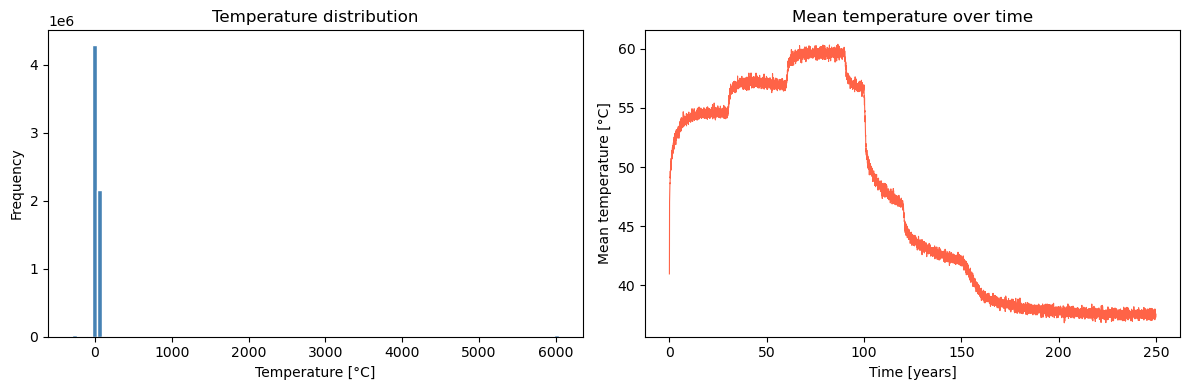

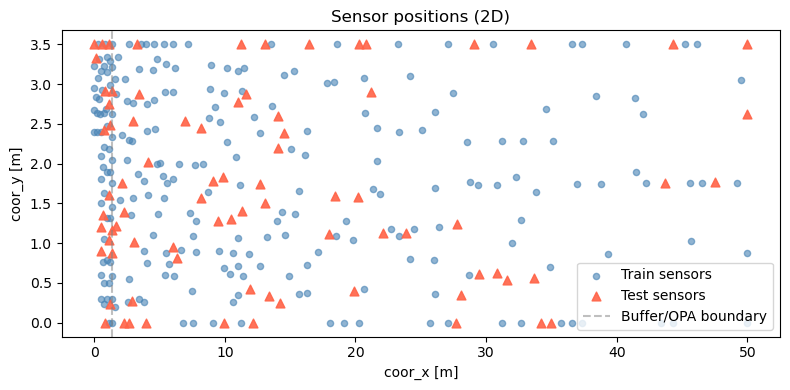

In [5]:
print(train_full['temperature'].describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))
print('Temperature min:', train_full['temperature'].min())
print('Temperature max:', train_full['temperature'].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_full['temperature'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Temperature distribution')
axes[0].set_xlabel('Temperature [°C]')
axes[0].set_ylabel('Frequency')

temp_by_time = train_full.groupby('time')['temperature'].mean()
axes[1].plot(temp_by_time.index / (365.25*24*3600), temp_by_time.values, color='tomato', linewidth=0.8)
axes[1].set_title('Mean temperature over time')
axes[1].set_xlabel('Time [years]')
axes[1].set_ylabel('Mean temperature [°C]')
plt.tight_layout()
plt.show()

# Sensor positions
train_sensors = set(train_full['sensor'].unique())
test_sensors  = set(test['sensor'].unique())
s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

plt.figure(figsize=(8, 4))
plt.scatter(s_train['coor_x'], s_train['coor_y'], c='steelblue', s=20, alpha=0.6, label='Train sensors')
plt.scatter(s_test['coor_x'],  s_test['coor_y'],  c='tomato',    s=40, alpha=0.9, marker='^', label='Test sensors')
plt.axvline(1.4, color='gray', linestyle='--', alpha=0.5, label='Buffer/OPA boundary')
plt.xlabel('coor_x [m]'); plt.ylabel('coor_y [m]')
plt.title('Sensor positions (2D)')
plt.legend(); plt.tight_layout(); plt.show()

## 6. Outlier Removal

Two complementary methods:
- **Global MAD** (Median Absolute Deviation): catches sensors with physically impossible temperatures
- **Local IQR per timestep**: catches values deviating too much from the distribution at a given moment

In [6]:
# Global outliers via MAD
temp        = train_full['temperature']
median_temp = temp.median()
mad_temp    = np.median(np.abs(temp - median_temp))
robust_z    = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)
train_full['is_global_outlier'] = robust_z.abs() > 6
print(f'Global outliers (MAD): {train_full["is_global_outlier"].sum()}')

# Local outliers per timestep via IQR
time_stats = (
    train_full.groupby('time')['temperature']
    .agg(time_median='median',
         time_q1=lambda x: x.quantile(0.25),
         time_q3=lambda x: x.quantile(0.75))
    .reset_index()
)
time_stats['time_iqr'] = time_stats['time_q3'] - time_stats['time_q1']
train_full = train_full.merge(time_stats, on='time', how='left')
train_full['is_local_outlier'] = (
    (train_full['temperature'] < train_full['time_median'] - 4.0 * train_full['time_iqr']) |
    (train_full['temperature'] > train_full['time_median'] + 4.0 * train_full['time_iqr'])
)
print(f'Local outliers (IQR): {train_full["is_local_outlier"].sum()}')

before_rows = len(train_full)
train_full  = train_full[
    (~train_full['is_global_outlier']) & (~train_full['is_local_outlier'])
].copy()
print(f'Rows removed: {before_rows - len(train_full)} | Remaining: {len(train_full)}')

cols_to_drop = ['is_global_outlier', 'is_local_outlier',
                'time_median', 'time_q1', 'time_q3', 'time_iqr']
train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Global outliers (MAD): 114636
Local outliers (IQR): 106226
Rows removed: 145193 | Remaining: 6382332


## 7. Sensor Drift Detection & Correction

Some sensors show a systematic linear drift in their residuals over time. We detect and correct this before training.

In [7]:
time_median = (
    train_full.groupby('time')['temperature']
    .median().rename('global_time_median').reset_index()
)
drift_df = train_full.merge(time_median, on='time', how='left').copy()
drift_df['temp_residual'] = drift_df['temperature'] - drift_df['global_time_median']

t_min = drift_df['time'].min()
t_max = drift_df['time'].max()
drift_df['time_norm_for_drift'] = (drift_df['time'] - t_min) / (t_max - t_min + 1e-8)

drift_records = []
for sensor_id, g in drift_df.groupby('sensor'):
    g = g.sort_values('time_norm_for_drift')
    if len(g) < 20:
        continue
    x = g['time_norm_for_drift'].values
    y = g['temp_residual'].values
    slope = np.polyfit(x, y, 1)[0] if np.std(y) > 1e-8 else 0.0
    corr  = np.corrcoef(x, y)[0, 1] if np.std(y) > 1e-8 else 0.0
    drift_records.append({'sensor': sensor_id, 'drift_slope': slope, 'drift_corr': corr})

sensor_drift    = pd.DataFrame(drift_records)
slope_abs       = sensor_drift['drift_slope'].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)
sensor_drift['is_drift_sensor'] = (
    (sensor_drift['drift_slope'].abs() > slope_threshold) &
    (sensor_drift['drift_corr'].abs() > 0.5)
)
drift_sensors = sensor_drift.loc[sensor_drift['is_drift_sensor'], 'sensor'].unique()
print(f'Drift sensors detected: {len(drift_sensors)}')

t_min = train_full['time'].min()
t_max = train_full['time'].max()
train_full['time_norm_for_drift'] = (train_full['time'] - t_min) / (t_max - t_min + 1e-8)
drift_map = sensor_drift.set_index('sensor')['drift_slope'].to_dict()
train_full['drift_correction'] = 0.0
for s in drift_sensors:
    mask = train_full['sensor'] == s
    train_full.loc[mask, 'drift_correction'] = (
        drift_map[s] * (train_full.loc[mask, 'time_norm_for_drift'] - 0.5)
    )
train_full['temperature'] = train_full['temperature'] - train_full['drift_correction']
train_full = train_full.drop(columns=['time_norm_for_drift', 'drift_correction'])
print('Drift correction applied.')

Drift sensors detected: 2
Drift correction applied.



## 8. Filter Replication 2

Each (sensor, timestep) has exactly 3 rows — one per experimental replication:
- **Rep 0**: 500W → 0W (drops around year 100)
- **Rep 1**: 1400W → 0W (drops around year 110)
- **Rep 2**: radioactive decay 1488W → 299W over 250 years

The test set matches **Rep 2 exclusively**. Training on Reps 0 and 1 would introduce noise from physically incompatible power scenarios.

In [8]:
train_full['rep'] = (
    train_full.groupby(['sensor', 'time'])['power']
    .rank(method='first').astype(int) - 1
)
for rep in [0, 1, 2]:
    sub = train_full[train_full['rep'] == rep]
    print(f'Rep {rep}: {sub.sensor.nunique()} sensors, {len(sub):,} rows')

train_full = train_full[train_full['rep'] == 2].drop(columns=['rep']).copy()
print(f'\nAfter filtering Rep 2: {len(train_full):,} rows, {train_full.sensor.nunique()} sensors')

Rep 0: 240 sensors, 2,190,126 rows
Rep 1: 240 sensors, 2,172,023 rows
Rep 2: 240 sensors, 2,020,183 rows

After filtering Rep 2: 2,020,183 rows, 240 sensors


## 9. Feature Engineering

Physics-motivated features:
- **dist_center / dist_canister**: temperature decays with distance from the heat source
- **is_opa**: zone indicator (OPA is weighted more in the Kaggle score)
- **time_log**: captures the logarithmic thermal diffusion dynamics
- **power_over_dist2**: heat flux proxy (inverse square law)
- **diffusion / diff_time**: thermal diffusion number
- **exp_decay**: exponential attenuation with distance
- **cum_energy**: total energy injected into the system
- **temp_neighbor_1/2/3**: temperatures of the 3 spatially nearest train sensors at same timestep
- **temp_weighted**: inverse-distance weighted interpolation from neighbors

In [9]:
eps = 1e-8
t_max_ref = train_full['time'].max()

def add_cum_energy(df):
    """Compute cumulative energy (power × dt) and merge back."""
    power_time = (
        df[['time', 'power']]
        .drop_duplicates(subset=['time'])
        .sort_values('time').copy()
    )
    power_time['dt']         = power_time['time'].diff().fillna(0)
    power_time['cum_energy'] = (power_time['power'] * power_time['dt']).cumsum()
    return df.merge(
        power_time[['time', 'cum_energy']].drop_duplicates(subset=['time']),
        on='time', how='left'
    )

def add_features(df, t_max_ref):
    """
    Add physics-motivated engineered features.
    t_max_ref: max time from training data for consistent time_norm on test.
    """
    df = df.copy()
    df['dist_center']      = np.sqrt(df['coor_x']**2 + df['coor_y']**2)
    df['dist_canister']    = np.sqrt((df['coor_x'] - 0.7)**2 + (df['coor_y'] - 1.2)**2)
    df['is_opa']           = (df['coor_x'] > 1.4).astype(float)
    df['time_norm']        = df['time'] / t_max_ref
    df['time_log']         = np.log1p(df['time'])
    df['power_over_dist2'] = df['power'] / (df['dist_canister']**2 + 0.01)
    df['diffusion']        = np.exp(-df['dist_canister'] / (np.sqrt(df['time'] + 1))) / (df['dist_canister'] + 0.1)
    df['diff_time']        = df['dist_canister']**2 / (df['time_norm'] + eps)
    df['exp_decay']        = np.exp(-df['dist_canister'] / 5.0)
    return df

train_full = add_cum_energy(train_full)
train_full = add_features(train_full, t_max_ref)
print('Features after engineering:', train_full.columns.tolist())

Features after engineering: ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'cum_energy', 'dist_center', 'dist_canister', 'is_opa', 'time_norm', 'time_log', 'power_over_dist2', 'diffusion', 'diff_time', 'exp_decay']


## 10. Neighbor Temperature Features

For each sensor position, we find the 3 spatially nearest training sensors and use their temperatures at the same timestep as features. This exploits the physical continuity of the thermal field — nearby sensors have correlated temperatures. We also add an inverse-distance weighted interpolation (Shepard's method).

In [10]:
def find_k_neighbors(pos_df, ref_pos_df, k, exclude_self=False):
    """Find k spatially nearest sensors for each sensor in pos_df."""
    result = {}
    for s in pos_df.index:
        x, y  = pos_df.loc[s, 'coor_x'], pos_df.loc[s, 'coor_y']
        dists = np.sqrt((ref_pos_df['coor_x'] - x)**2 + (ref_pos_df['coor_y'] - y)**2)
        if exclude_self and s in dists.index:
            dists = dists.drop(s)
        result[s] = dists.nsmallest(k).index.tolist()
    return result

def add_neighbor_temps(df, nbrs, temp_pivot):
    """
    Add temperature of the 3 nearest train sensors at the same timestep.
    Exploits the physical continuity of the thermal field.
    """
    df    = df.copy().reset_index(drop=True)
    t_idx = pd.Index(temp_pivot.index)
    s_idx = pd.Index(temp_pivot.columns)
    arr   = temp_pivot.values
    for i in range(3):
        nbr_map          = pd.Series({s: nbrs[s][i] for s in nbrs if s in df['sensor'].values})
        neighbor_sensors = df['sensor'].map(nbr_map).values
        time_vals        = df['time'].values
        row_ids = t_idx.get_indexer(time_vals)
        col_ids = s_idx.get_indexer(neighbor_sensors)
        temps   = np.where(
            (row_ids >= 0) & (col_ids >= 0),
            arr[np.clip(row_ids, 0, len(arr)-1), np.clip(col_ids, 0, arr.shape[1]-1)],
            np.nan
        )
        df[f'temp_neighbor_{i+1}'] = temps
    for i in range(3):
        col = f'temp_neighbor_{i+1}'
        df[col] = df[col].fillna(df[col].median())
    return df

def add_weighted_neighbor(df, nbrs, temp_pivot, sensor_pos):
    """
    Inverse-distance weighted temperature interpolation (Shepard's method).
    Closer neighbors contribute more than distant ones.
    """
    df    = df.copy().reset_index(drop=True)
    t_idx = pd.Index(temp_pivot.index)
    s_idx = pd.Index(temp_pivot.columns)
    arr   = temp_pivot.values
    weighted_temps = np.zeros(len(df))
    total_weights  = np.zeros(len(df))
    for i in range(3):
        nbr_map          = pd.Series({s: nbrs[s][i] for s in nbrs if s in df['sensor'].values})
        neighbor_sensors = df['sensor'].map(nbr_map).values
        time_vals        = df['time'].values
        row_ids = t_idx.get_indexer(time_vals)
        col_ids = s_idx.get_indexer(neighbor_sensors)
        temps   = np.where(
            (row_ids >= 0) & (col_ids >= 0),
            arr[np.clip(row_ids, 0, len(arr)-1), np.clip(col_ids, 0, arr.shape[1]-1)],
            np.nan
        )
        nbr_pos = sensor_pos.loc[
            neighbor_sensors.tolist() if hasattr(neighbor_sensors, 'tolist') else neighbor_sensors
        ]
        dists   = np.sqrt(
            (df['coor_x'].values - nbr_pos['coor_x'].values)**2 +
            (df['coor_y'].values - nbr_pos['coor_y'].values)**2
        ) + 0.01
        weights = 1 / dists
        valid   = ~np.isnan(temps)
        weighted_temps += np.where(valid, weights * temps, 0)
        total_weights  += np.where(valid, weights, 0)
    df['temp_weighted'] = np.where(total_weights > 0, weighted_temps / total_weights, np.nan)
    df['temp_weighted'] = df['temp_weighted'].fillna(df['temp_weighted'].median())
    return df

# Sensor positions
sensor_pos = sensors.set_index('sensor')[['coor_x', 'coor_y']]
train_pos  = sensor_pos.loc[sensor_pos.index.isin(train_full['sensor'].unique())]
test_pos   = sensor_pos.loc[sensor_pos.index.isin(test['sensor'].unique())]

# Compute neighbors
print('Computing neighbors...')
train_nbrs = find_k_neighbors(train_pos, train_pos, 5, exclude_self=True)
test_nbrs  = find_k_neighbors(test_pos,  train_pos, 5)

# Pivot table for fast lookup
temp_pivot = train_full.pivot_table(index='time', columns='sensor', values='temperature')
print(f'Pivot shape: {temp_pivot.shape}')

# Add neighbor features
train_full = add_neighbor_temps(train_full, train_nbrs, temp_pivot)
train_full = add_weighted_neighbor(train_full, train_nbrs, temp_pivot, sensor_pos)
print(f'Neighbor NaN train: {train_full["temp_neighbor_1"].isna().sum()}')

Computing neighbors...
Pivot shape: (9128, 240)
Neighbor NaN train: 0


## 11. Final Checks

In [11]:
print('Final train_full shape:', train_full.shape)
print('Missing values:')
print(train_full.isna().sum())
assert train_full['temperature'].notna().all()
assert np.isfinite(train_full['temperature']).all()
print('All checks passed.')

Final train_full shape: (2020183, 21)
Missing values:
sensor              0
time                0
power               0
temperature         0
coor_x              0
coor_y              0
coor_z              0
cum_energy          0
dist_center         0
dist_canister       0
is_opa              0
time_norm           0
time_log            0
power_over_dist2    0
diffusion           0
diff_time           0
exp_decay           0
temp_neighbor_1     0
temp_neighbor_2     0
temp_neighbor_3     0
temp_weighted       0
dtype: int64
All checks passed.


## 12. Train/Validation Split by Sensor

We split by sensor (not by row) to properly evaluate generalization to unseen sensor positions — the actual test scenario. A row-based split would leak spatial information between train and validation.

Train sensors: 192 | Rows: 1,617,450
Val   sensors: 48   | Rows: 402,733


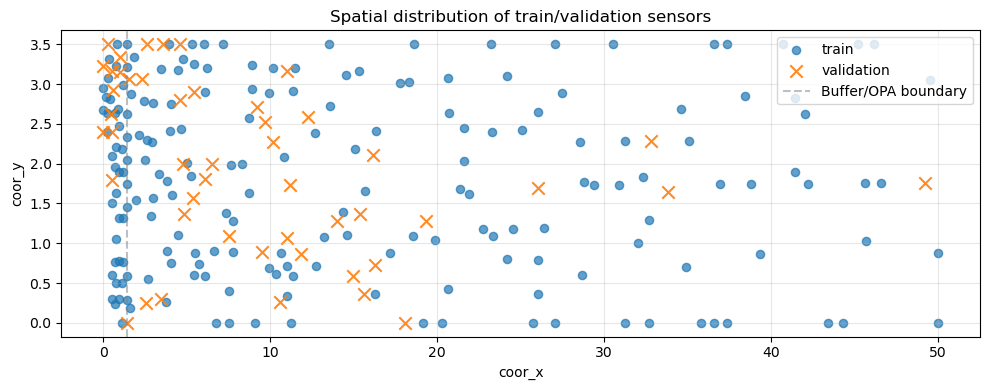

In [12]:
TARGET   = 'temperature'
FEATURES = [
    'coor_x', 'coor_y',
    'time_norm', 'time_log',
    'power', 'cum_energy',
    'dist_center', 'dist_canister', 'is_opa',
    'diffusion', 'power_over_dist2', 'diff_time', 'exp_decay',
    'temp_neighbor_1', 'temp_neighbor_2', 'temp_neighbor_3',
    'temp_weighted'
]

unique_sensors = train_full['sensor'].unique()
rng            = np.random.default_rng(42)
val_sensors    = rng.choice(unique_sensors, size=int(0.2 * len(unique_sensors)), replace=False)
train_sensors  = np.setdiff1d(unique_sensors, val_sensors)

train_df = train_full[train_full['sensor'].isin(train_sensors)].copy()
val_df   = train_full[train_full['sensor'].isin(val_sensors)].copy()

assert set(train_df['sensor']).isdisjoint(set(val_df['sensor']))
print(f'Train sensors: {train_df.sensor.nunique()} | Rows: {len(train_df):,}')
print(f'Val   sensors: {val_df.sensor.nunique()}   | Rows: {len(val_df):,}')

# Visualize train/val sensor positions
train_sensor_pos = train_df.groupby('sensor')[['coor_x', 'coor_y']].mean().reset_index()
val_sensor_pos   = val_df.groupby('sensor')[['coor_x', 'coor_y']].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.scatter(train_sensor_pos['coor_x'], train_sensor_pos['coor_y'], s=35, label='train', alpha=0.7)
plt.scatter(val_sensor_pos['coor_x'],   val_sensor_pos['coor_y'],   s=80, label='validation', alpha=0.9, marker='x')
plt.axvline(1.4, color='gray', linestyle='--', alpha=0.5, label='Buffer/OPA boundary')
plt.xlabel('coor_x'); plt.ylabel('coor_y')
plt.title('Spatial distribution of train/validation sensors')
plt.legend(loc='upper right'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 13. Normalisation

In [13]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_val   = val_df[FEATURES].values
y_val   = val_df[TARGET].values

# Fit scaler ONLY on training data
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

print(f'X_train: {X_train_s.shape} | X_val: {X_val_s.shape}')
print(f'NaN/Inf in X_train_s: {np.isnan(X_train_s).sum()} / {np.isinf(X_train_s).sum()}')
print(f'NaN/Inf in X_val_s  : {np.isnan(X_val_s).sum()} / {np.isinf(X_val_s).sum()}')

X_train: (1617450, 17) | X_val: (402733, 17)
NaN/Inf in X_train_s: 0 / 0
NaN/Inf in X_val_s  : 0 / 0


## 14. Model — Random Forest

Random Forest trains T independent decision trees on different data subsamples and averages their predictions:

$$\hat{y} = \frac{1}{T}\sum_{t=1}^{T} h_t(\mathbf{x})$$

This ensemble approach reduces variance compared to a single tree, captures non-linear interactions between position, time and power, and provides built-in feature importance. It is well-suited for tabular data with physics-motivated features.

In [14]:
# Subsample for faster training (RF scales quadratically with n_samples)
SAMPLE_SIZE = 500_000
idx_rf = np.random.choice(len(X_train_s), size=min(SAMPLE_SIZE, len(X_train_s)), replace=False)
print(f'Training on {len(idx_rf):,} samples out of {len(X_train_s):,}')

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_s[idx_rf], y_train[idx_rf])
print('Training done.')

Training on 500,000 samples out of 1,617,450
Training done.


## 15. Evaluate on Validation Set

In [15]:
y_val_pred = rf.predict(X_val_s)

mae  = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2   = r2_score(y_val, y_val_pred)

print(f'Validation MAE  : {mae:.4f} °C')
print(f'Validation RMSE : {rmse:.4f} °C')
print(f'Validation R²   : {r2:.4f}')

# Train RMSE to check for overfitting
y_train_pred = rf.predict(X_train_s[idx_rf])
rmse_train   = np.sqrt(mean_squared_error(y_train[idx_rf], y_train_pred))
print(f'\nTrain RMSE : {rmse_train:.4f} °C  (gap = {rmse - rmse_train:.4f})')

Validation MAE  : 2.9367 °C
Validation RMSE : 6.1878 °C
Validation R²   : 0.8136

Train RMSE : 2.0028 °C  (gap = 4.1850)


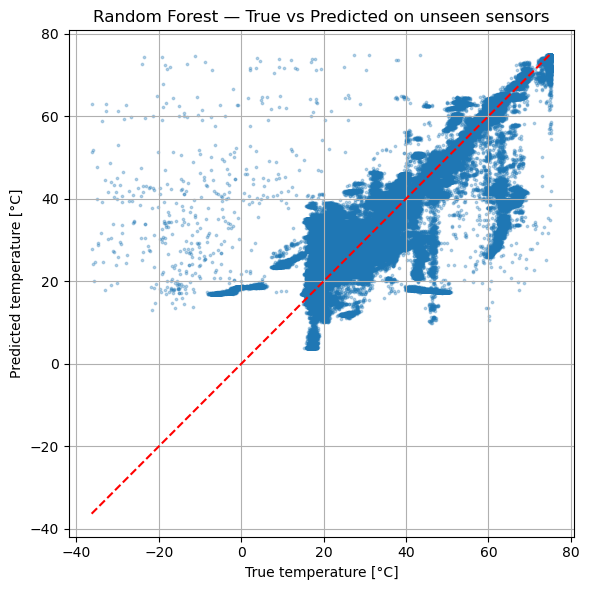

In [16]:
# True vs predicted scatter
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_val_pred, s=3, alpha=0.3)
mn, mx = min(y_val.min(), y_val_pred.min()), max(y_val.max(), y_val_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('True temperature [°C]')
plt.ylabel('Predicted temperature [°C]')
plt.title('Random Forest — True vs Predicted on unseen sensors')
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Feature Importance

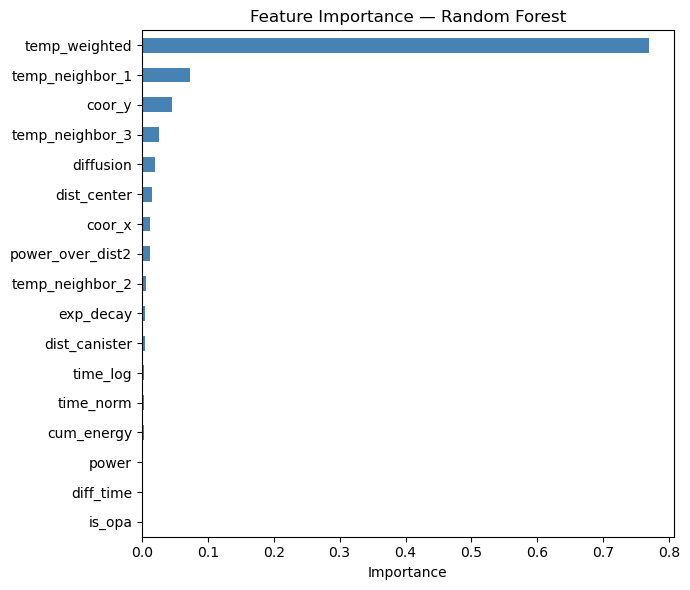

In [17]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(7, 6), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 17. Error Analysis by Sensor

Worst sensors by RMSE:
              mae       rmse     coor_x    coor_y
sensor                                           
N749    16.561715  19.075242  15.646701  0.356862
N186    11.956029  18.111370   0.000000  3.225000
N185     9.395877  14.096158   0.280000  3.500000
N862    12.028459  13.981009   6.525898  1.996336
N201     9.187332  11.749787   0.500000  1.800000
N236     9.373133  11.135365  26.063416  1.689136
N413     4.699577   7.879279   4.860546  1.365552
N4       5.218506   7.869293   1.400000  0.000000
N702     4.647987   6.173201  12.254921  2.582809
N732     3.190986   5.673422   2.560348  0.254275


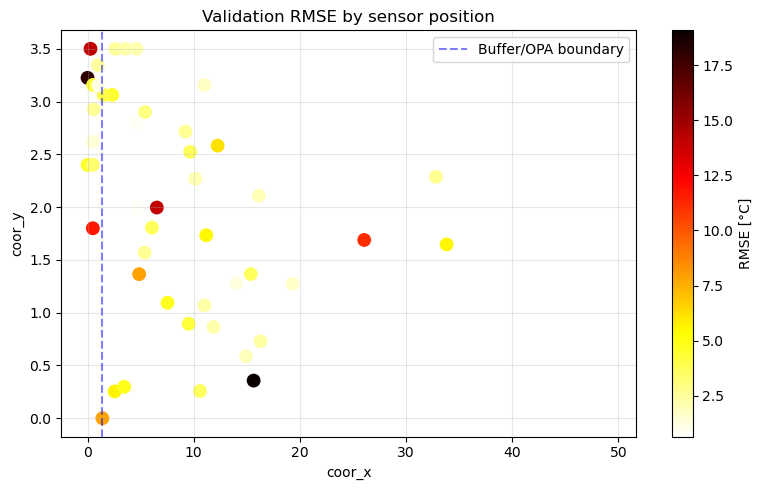

In [18]:
val_results = val_df.copy()
val_results['y_true']    = y_val
val_results['y_pred']    = y_val_pred
val_results['abs_error'] = np.abs(y_val - y_val_pred)
val_results['sq_error']  = (y_val - y_val_pred)**2

sensor_metrics = (
    val_results
    .groupby('sensor')
    .agg(
        mae  =('abs_error', 'mean'),
        rmse =('sq_error',  lambda x: np.sqrt(np.mean(x))),
        coor_x=('coor_x', 'first'),
        coor_y=('coor_y', 'first'),
    )
    .sort_values('rmse', ascending=False)
)
print('Worst sensors by RMSE:')
print(sensor_metrics.head(10))

# Spatial error map
plt.figure(figsize=(8, 5))
sc = plt.scatter(
    sensor_metrics['coor_x'], sensor_metrics['coor_y'],
    c=sensor_metrics['rmse'], cmap='hot_r', s=80
)
plt.colorbar(sc, label='RMSE [°C]')
plt.axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA boundary')
plt.xlabel('coor_x'); plt.ylabel('coor_y')
plt.title('Validation RMSE by sensor position')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 18. MAE over Time

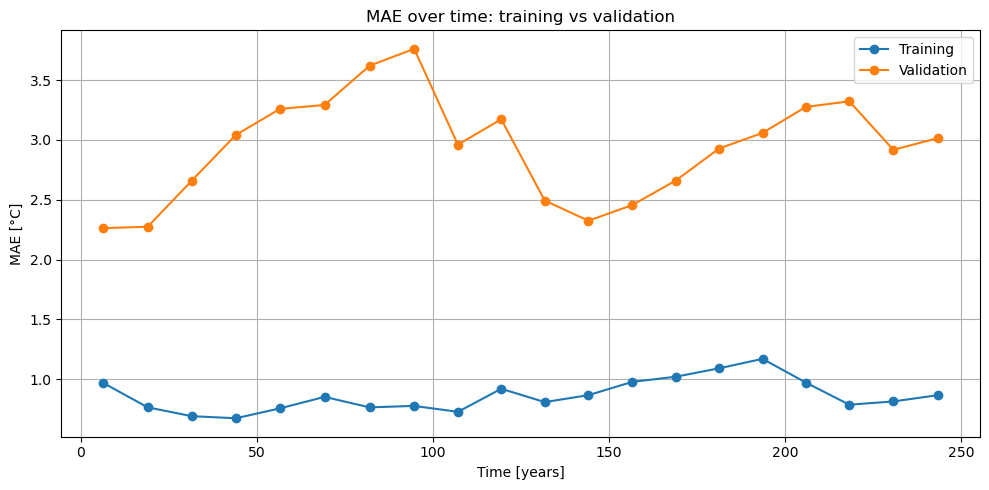

In [19]:
train_results = train_df.copy()
train_results['y_pred']    = rf.predict(X_train_s)
train_results['abs_error'] = np.abs(train_results['temperature'] - train_results['y_pred'])
val_results['abs_error']   = np.abs(val_results['y_true'] - val_results['y_pred'])

train_results['time_years'] = train_results['time'] / (365.25 * 24 * 3600)
val_results['time_years']   = val_results['time']   / (365.25 * 24 * 3600)

all_time_years = pd.concat([train_results['time_years'], val_results['time_years']])
time_bins = pd.qcut(all_time_years, q=20, duplicates='drop').cat.categories

train_time_error = (
    train_results
    .groupby(pd.cut(train_results['time_years'], bins=time_bins, include_lowest=True), observed=False)
    .agg(train_mae=('abs_error', 'mean')).reset_index()
)
val_time_error = (
    val_results
    .groupby(pd.cut(val_results['time_years'], bins=time_bins, include_lowest=True), observed=False)
    .agg(val_mae=('abs_error', 'mean')).reset_index()
)
train_time_error['time_mid'] = train_time_error['time_years'].apply(lambda x: x.mid)
val_time_error['time_mid']   = val_time_error['time_years'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 5))
plt.plot(train_time_error['time_mid'], train_time_error['train_mae'], marker='o', label='Training')
plt.plot(val_time_error['time_mid'],   val_time_error['val_mae'],     marker='o', label='Validation')
plt.xlabel('Time [years]'); plt.ylabel('MAE [°C]')
plt.title('MAE over time: training vs validation')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## 19. Final Predictions & Submission

In [20]:
# Build test_full with same pipeline
test_full = test.merge(sensors, on='sensor', how='left')
test_full = add_cum_energy(test_full)
test_full = add_features(test_full, t_max_ref)
test_full = add_neighbor_temps(test_full, test_nbrs, temp_pivot)
test_full = add_weighted_neighbor(test_full, test_nbrs, temp_pivot, sensor_pos)

X_test_s = scaler.transform(test_full[FEATURES].values)
assert len(X_test_s) == len(test)
print(f'X_test_s: {X_test_s.shape}')

y_pred = rf.predict(X_test_s)

submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})
assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'Random Forest — Validation RMSE: {rmse:.4f} °C')
print(f'submission.csv saved — {len(submission)} rows')
display(submission.head())

X_test_s: (2190480, 17)
Random Forest — Validation RMSE: 6.1878 °C
submission.csv saved — 2190480 rows


,Id,temperature
0,0,17.030955
1,1,17.065907
2,2,17.064963
3,3,17.079861
4,4,17.066896


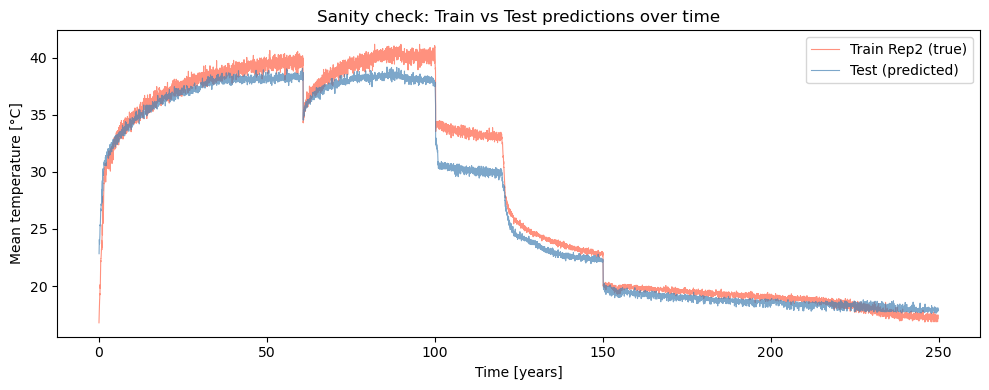

In [21]:
# Sanity check: train vs test predictions over time
test_full['temp_pred'] = y_pred
temp_train = train_full.groupby('time')['temperature'].mean()
temp_pred  = test_full.groupby('time')['temp_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_train.index / (365.25*24*3600), temp_train.values,
         label='Train Rep2 (true)', color='tomato', alpha=0.7, linewidth=0.8)
plt.plot(temp_pred.index / (365.25*24*3600), temp_pred.values,
         label='Test (predicted)', color='steelblue', alpha=0.7, linewidth=0.8)
plt.title('Sanity check: Train vs Test predictions over time')
plt.xlabel('Time [years]'); plt.ylabel('Mean temperature [°C]')
plt.legend(); plt.tight_layout(); plt.show()

## 20. Spatial Temperature Map: True vs Predicted

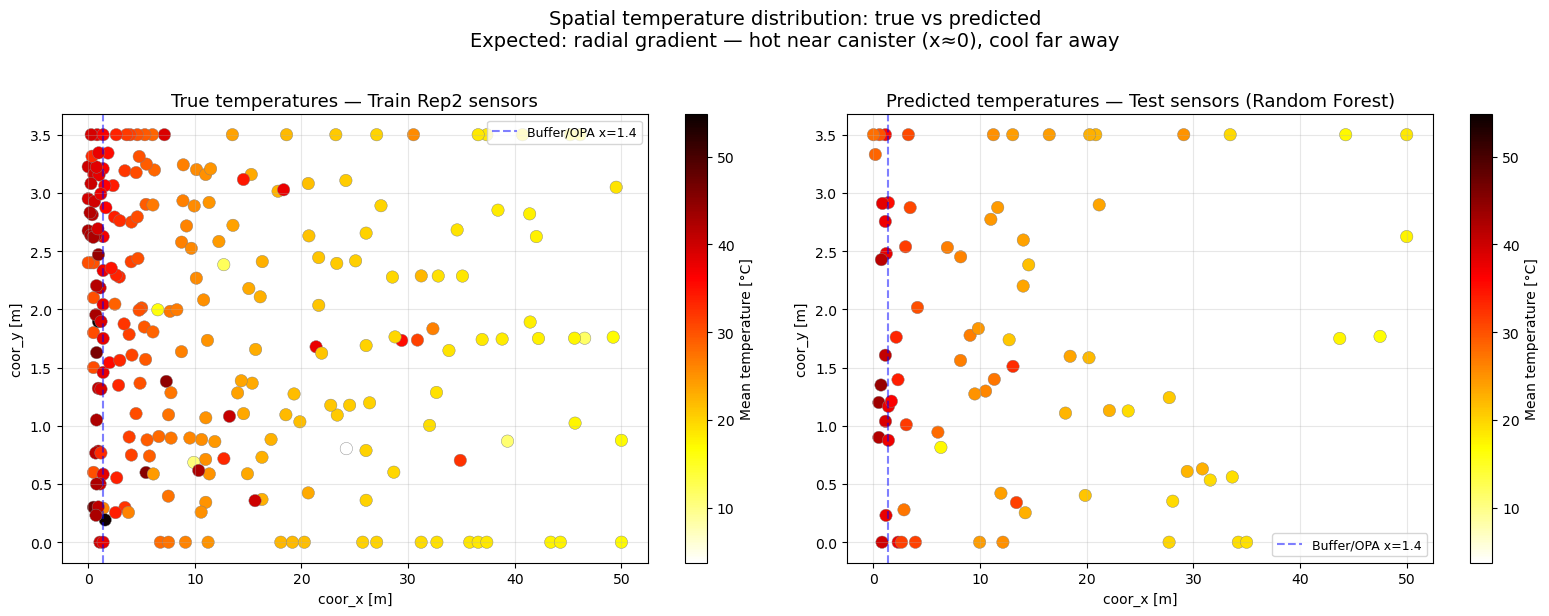

In [22]:
train_sensor_temp = (
    train_full.groupby('sensor')
    .agg(coor_x=('coor_x', 'first'), coor_y=('coor_y', 'first'), mean_temp=('temperature', 'mean'))
    .reset_index()
)
test_sensor_temp = (
    test_full.groupby('sensor')
    .agg(coor_x=('coor_x', 'first'), coor_y=('coor_y', 'first'), mean_temp=('temp_pred', 'mean'))
    .reset_index()
)

vmin = min(train_sensor_temp['mean_temp'].min(), test_sensor_temp['mean_temp'].min())
vmax = max(train_sensor_temp['mean_temp'].max(), test_sensor_temp['mean_temp'].max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(
    train_sensor_temp['coor_x'], train_sensor_temp['coor_y'],
    c=train_sensor_temp['mean_temp'], cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[0].axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA x=1.4')
axes[0].set_title('True temperatures — Train Rep2 sensors', fontsize=13)
axes[0].set_xlabel('coor_x [m]'); axes[0].set_ylabel('coor_y [m]')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Mean temperature [°C]')

sc2 = axes[1].scatter(
    test_sensor_temp['coor_x'], test_sensor_temp['coor_y'],
    c=test_sensor_temp['mean_temp'], cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[1].axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA x=1.4')
axes[1].set_title('Predicted temperatures — Test sensors (Random Forest)', fontsize=13)
axes[1].set_xlabel('coor_x [m]'); axes[1].set_ylabel('coor_y [m]')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='Mean temperature [°C]')

plt.suptitle('Spatial temperature distribution: true vs predicted\n'
             'Expected: radial gradient — hot near canister (x≈0), cool far away',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()